<a href="https://colab.research.google.com/github/bychahinez/Driver-Drowsines/blob/main/Drowsiness_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Mount Google Drive

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Quick sanity check — confirm the mount worked
assert os.path.exists('/content/drive/MyDrive'), (
    "Drive mount failed. Re-run this cell and authorise access."
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Separate Dataset Into Two Tasks (Eye vs Yawn)

In [ ]:
import os
import shutil

source_dir = "/content/drive/MyDrive/train"

eye_dataset = "/content/drive/MyDrive/drowsiness_dataset/eye_dataset"
yawn_dataset = "/content/drive/MyDrive/drowsiness_dataset/yawn_dataset"

classes_eye = ["Closed", "Open"]
classes_yawn = ["yawn", "no_yawn"]

for c in classes_eye:
    os.makedirs(os.path.join(eye_dataset, c), exist_ok=True)

for c in classes_yawn:
    os.makedirs(os.path.join(yawn_dataset, c), exist_ok=True)


for cls in os.listdir(source_dir):

    src_class_path = os.path.join(source_dir, cls)

    if cls in classes_eye:
        dst = os.path.join(eye_dataset, cls)

    elif cls in classes_yawn:
        dst = os.path.join(yawn_dataset, cls)

    else:
        continue

    for img in os.listdir(src_class_path):
        src_file = os.path.join(src_class_path, img)
        dst_file = os.path.join(dst, img)

        shutil.copy(src_file, dst_file)

print("Dataset separated successfully.")

Dataset separated successfully.


Code to split each class separately and combine ( eye dataset)

In [ ]:
import os
import random
import shutil

source_dir = "/content/drive/MyDrive/drowsiness_dataset/eye_dataset"
dest_dir = "/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split"

classes = ["Closed", "Open"]

# create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(dest_dir, split, cls), exist_ok=True)

# split each class independently
for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.8 * total)
    val_end = int(0.9 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # copy train
    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "train", cls, img)
        )

    # copy val
    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "val", cls, img)
        )

    # copy test
    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "test", cls, img)
        )

Code to split each class separately and combine ( yawn dataset)

In [ ]:
import os
import random
import shutil

source_dir = "/content/drive/MyDrive/drowsiness_dataset/yawn_dataset"
dest_dir = "/content/drive/MyDrive/drowsiness_dataset/yawn_dataset_split"

classes = ["yawn", "no_yawn"]

# create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(dest_dir, split, cls), exist_ok=True)

# split each class independently
for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.8 * total)
    val_end = int(0.9 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # copy train
    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "train", cls, img)
        )

    # copy val
    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "val", cls, img)
        )

    # copy test
    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(dest_dir, "test", cls, img)
        )


Define transformations

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),           # Resize all images to 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
    transforms.RandomRotation(10),           # Random rotation ±10°
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),                                       # Random color changes
    transforms.ToTensor(),                   # Convert to tensor
])
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


Load datasets with transformations

In [ ]:
#For eyes model:
eye_train = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/train", transform=train_transforms)
eye_val   = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/val", transform=test_transforms)
eye_test  = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/test", transform=test_transforms)

#For yawn model:
yawn_train = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/yawn_dataset_split/train", transform=train_transforms)
yawn_val   = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/yawn_dataset_split/val", transform=test_transforms)
yawn_test  = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/yawn_dataset_split/test", transform=test_transforms)

Wrap in DataLoader

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

eye_train_loader = DataLoader(eye_train, batch_size=batch_size, shuffle=True)
eye_val_loader   = DataLoader(eye_val, batch_size=batch_size)
eye_test_loader  = DataLoader(eye_test, batch_size=batch_size)

yawn_train_loader = DataLoader(yawn_train, batch_size=batch_size, shuffle=True)
yawn_val_loader   = DataLoader(yawn_val, batch_size=batch_size)
yawn_test_loader  = DataLoader(yawn_test, batch_size=batch_size)

Visual check of augmentation

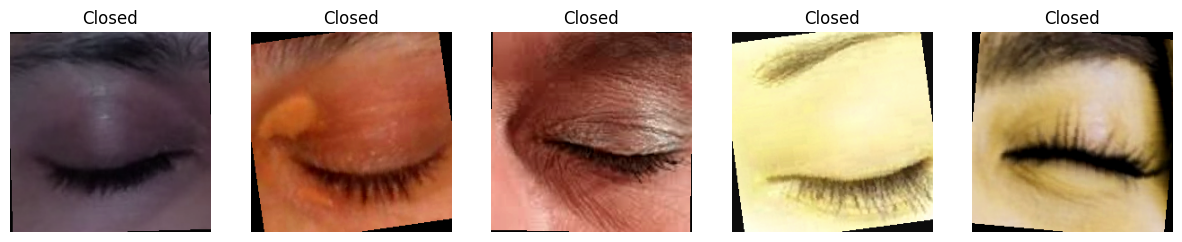

In [ ]:
import matplotlib.pyplot as plt
import torchvision

def show_augmented(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # C,H,W → H,W,C
        axes[i].imshow(img)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis('off')
    plt.show()

show_augmented(eye_train)

Load MobileNetV2 in PyTorch

In [ ]:
import torchvision.models as models

model = models.mobilenet_v2(pretrained=True)

print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


MobileNetV2 model (fine-tuning last block + classifier)

In [ ]:
mobilenet = models.mobilenet_v2(pretrained=True)

# Freeze first 80–90% of features
for param in mobilenet.features[:14].parameters():
    param.requires_grad = False

# Replace classifier for 2 classes
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(mobilenet.last_channel, 2)  # 2 classes: Closed, Open
)

mobilenet = mobilenet.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {'params': mobilenet.features[14:].parameters(), 'lr': 1e-4},  # last block
    {'params': mobilenet.classifier.parameters(), 'lr': 1e-3}      # classifier
])

In [ ]:
batch_size = 32

eye_train = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/train", transform=train_transforms)
eye_val   = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/val", transform=test_transforms)
eye_test  = ImageFolder("/content/drive/MyDrive/drowsiness_dataset/eye_dataset_split/test", transform=test_transforms)

train_loader = DataLoader(eye_train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(eye_val, batch_size=batch_size)
test_loader  = DataLoader(eye_test, batch_size=batch_size)

In [ ]:
num_epochs = 20  # start with 20, max epochs
patience = 5     # stop if val_acc doesn't improve for 5 consecutive epochs
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(num_epochs):
    # --- Training ---
    mobilenet.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = train_loss / total

    # --- Validation ---
    mobilenet.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = val_loss / total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # --- Early stopping logic ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        # Save best model
        torch.save(mobilenet.state_dict(), "/content/drive/MyDrive/eye_model_best.pth")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"⏹ Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/20 | Train Loss: 0.1131, Train Acc: 0.9580 | Val Loss: 0.0067, Val Acc: 0.9983
Epoch 2/20 | Train Loss: 0.0071, Train Acc: 0.9986 | Val Loss: 0.0063, Val Acc: 0.9983
Epoch 3/20 | Train Loss: 0.0176, Train Acc: 0.9952 | Val Loss: 0.0202, Val Acc: 0.9933
Epoch 4/20 | Train Loss: 0.0071, Train Acc: 0.9959 | Val Loss: 0.0022, Val Acc: 1.0000
Epoch 5/20 | Train Loss: 0.0223, Train Acc: 0.9931 | Val Loss: 0.0027, Val Acc: 1.0000
Epoch 6/20 | Train Loss: 0.0093, Train Acc: 0.9945 | Val Loss: 0.0126, Val Acc: 0.9967
Epoch 7/20 | Train Loss: 0.0012, Train Acc: 1.0000 | Val Loss: 0.0015, Val Acc: 1.0000
Epoch 8/20 | Train Loss: 0.0014, Train Acc: 1.0000 | Val Loss: 0.0005, Val Acc: 1.0000
Epoch 9/20 | Train Loss: 0.0033, Train Acc: 0.9979 | Val Loss: 0.0005, Val Acc: 1.0000
⏹ Early stopping triggered at epoch 9


In [ ]:
mobilenet.load_state_dict(torch.load("/content/drive/MyDrive/eye_model_best.pth"))
mobilenet.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"✅ Test Accuracy: {test_acc:.4f}")

✅ Test Accuracy: 1.0000
